# BDIFF — Base de Données sur les Incendies de Forêts en France

**Source** : https://bdiff.agriculture.gouv.fr/incendies · export par tranches (limite 30 000 lignes)
**Période** : 1973 → 2025 · **Granularité** : un feu = une ligne, localisée au code INSEE

---

### Ce que ce notebook doit établir

| # | Question | Pourquoi c'est bloquant |
|---|---|---|
| 1 | Les exports se recouvrent-ils ? | Les plages demandées se touchent à minuit — risque de double comptage |
| 2 | **La date est-elle une date d'éclosion ou de saisie ?** | Elle décide de la granularité du modèle : **jour** ou **semaine** |
| 3 | Quelle est la couverture territoriale selon l'époque ? | Un modèle peut apprendre la géographie de la *collecte* au lieu de celle du *risque* |

> Règle de travail : **une question → une figure → une réponse.**

## 1. Chargement

Les archives sont lues **directement depuis les ZIP**, sans décompression sur disque.

⚠️ Deux pièges de format repérés à l'ouverture :
- la **ligne d'en-tête n'est pas la même** d'un fichier à l'autre (3ᵉ, 4ᵉ ou 7ᵉ) — on la détecte au lieu de la coder en dur ;
- certains fichiers documentent des **pertes de données** dans leurs métadonnées : on les récupère.

In [ ]:
# ── enregistrement automatique des figures ──
# chaque plt.show() écrit aussi un PNG dans figures/data-bdiff/
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from tvfed.figures import activer

activer("data-bdiff")

In [1]:
import pandas as pd, numpy as np, zipfile, io, re
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── chemins : marche depuis notebook/ comme depuis la racine ──
def _trouve(sc):
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / sc).exists():
            return p / sc
    raise FileNotFoundError(f"'{sc}' introuvable depuis {Path.cwd()}")

BDIFF_DIR = _trouve("data/BDIFF")
ZIPS = sorted(BDIFF_DIR.glob("*.zip"))

# ── charte graphique (identique au notebook Copernicus) ──
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLEU, ORANGE, ROUGE, VERT = "#2a78d6", "#eb6834", "#e34948", "#1baf7a"
CM_ANNEES = LinearSegmentedColormap.from_list("an", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
DEB_MOIS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

print(f"📂 {len(ZIPS)} archives — {BDIFF_DIR}")
for z in ZIPS:
    print(f"   {z.name:22s} {z.stat().st_size/1e6:5.1f} Mo")

📂 6 archives — c:\Users\romua\Documents\La_Plateforme_\Projet 1 - TERRE FEU VENT EAU DATA\terre-vent-feu-eau-data\data\BDIFF
   incendies (1).zip        1.1 Mo
   incendies (2).zip        1.0 Mo
   incendies (3).zip        1.1 Mo
   incendies (4).zip        1.2 Mo
   incendies (5).zip        0.7 Mo
   incendies.zip            1.1 Mo


In [2]:
"""Chargement — lecture directe des ZIP, sans décompression sur disque."""

def lire_zip(zpath):
    """Retourne (DataFrame, métadonnées). L'en-tête n'est PAS à la même ligne
    selon les fichiers (4, 7 ou 3) : on la détecte au lieu de la coder en dur."""
    with zipfile.ZipFile(zpath) as z:
        nom_csv = next(n for n in z.namelist() if n.lower().endswith("incendies.csv"))
        brut = z.read(nom_csv).decode("utf-8")

    lignes = brut.splitlines()
    i_ent = next(i for i, l in enumerate(lignes) if l.startswith("Année;Numéro"))

    meta = {"fichier": zpath.name, "ligne_entete": i_ent, "notes": []}
    for l in lignes[:i_ent]:
        if m := re.search(r"de\s*:\s*(\d{4}-\d{2}-\d{2}).*?jusqu'à\s*:\s*(\d{4}-\d{2}-\d{2})", l):
            meta["debut"], meta["fin"] = m.group(1), m.group(2)
        if m := re.search(r"sélection\s*:\s*(\d+)", l):
            meta["annonce"] = int(m.group(1))
        # ⚠️ certains fichiers documentent des pertes de données dans l'en-tête
        if re.match(r'^"\d{4}\s*-\s*\d+\s*:', l):
            meta["notes"].append(l.replace('";"', ' ').strip('"'))

    df = pd.read_csv(io.StringIO("\n".join(lignes[i_ent:])), sep=";",
                     dtype={"Département": str, "Code INSEE": str}, low_memory=False)
    meta["lignes"] = len(df)
    return df, meta

frames, METAS = [], []
for z in ZIPS:
    df, meta = lire_zip(z)
    df["_source"] = z.name
    frames.append(df); METAS.append(meta)

BRUT = pd.concat(frames, ignore_index=True)
META = pd.DataFrame(METAS)

print("Plages demandées à la BDIFF et volumes obtenus :\n")
print(META[["fichier", "debut", "fin", "ligne_entete", "annonce", "lignes"]].to_string(index=False))
print(f"\nTOTAL brut : {len(BRUT):,} lignes")

notes = [n for ns in META.notes for n in ns]
if notes:
    print("\n⚠️  Pertes de données documentées par la BDIFF elle-même :")
    for n in notes:
        print(f"     {n}")

Plages demandées à la BDIFF et volumes obtenus :

          fichier      debut        fin  ligne_entete  annonce  lignes
incendies (1).zip 1983-01-01 1993-01-01             3    27901   27901
incendies (2).zip 1993-01-01 2003-01-01             3    24875   24875
incendies (3).zip 2003-01-01 2013-01-01             6    26220   26220
incendies (4).zip 2013-01-01 2023-01-01             3    27390   27390
incendies (5).zip 2023-01-01 2025-12-31             2     6588    6588
    incendies.zip 1966-01-01 1983-01-01             3    29813   29813

TOTAL brut : 142,787 lignes

⚠️  Pertes de données documentées par la BDIFF elle-même :
     2011 - 64 :  Aucune donnée disponible.
     2010 - 64 :  Données perdues suite à un incident technique.


## 2. Audit qualité

Trois vérifications : l'intégrité (a-t-on bien tout lu ?), **les doublons de frontière** (l'hypothèse à tester), et les valeurs manquantes.

In [3]:
"""Audit qualité — intégrité, doublons de frontière, valeurs manquantes."""

# ── 1. intégrité : ce que la BDIFF annonce vs ce qu'on a lu ──
ok = (META.annonce == META.lignes).all()
print(f"1. INTÉGRITÉ — lignes lues = nombre annoncé par la BDIFF : {'✅' if ok else '❌'}")

# ── 2. L'HYPOTHÈSE DES DOUBLONS DE FRONTIÈRE ──
# Les plages demandées se touchent (…→1983-01-01 puis 1983-01-01→…) : un feu
# du 1er janvier pourrait donc apparaître dans DEUX fichiers. On vérifie.
print("\n2. DOUBLONS DE FRONTIÈRE (bornes qui se touchent à minuit)")
bornes = []
for i in range(len(META) - 1):
    a, b = META.sort_values("debut").iloc[i], META.sort_values("debut").iloc[i + 1]
    bornes.append((a.fin, b.debut, a.fin == b.debut))
for fin, deb, touche in bornes:
    print(f"   fin {fin}  →  début {deb}   {'⚠️ se touchent' if touche else 'disjointes'}")

CLES = {
    "ligne entière":                  None,
    "Année + Numéro":                 ["Année", "Numéro"],
    "Année + Numéro + Dépt":          ["Année", "Numéro", "Département"],
    "INSEE + date + surface":         ["Code INSEE", "Date de première alerte", "Surface parcourue (m2)"],
}
print()
for nom, cle in CLES.items():
    n = BRUT.duplicated().sum() if cle is None else BRUT.duplicated(subset=cle).sum()
    print(f"   doublons sur {nom:28s} : {n:,}  {'✅' if n == 0 else '❌'}")

# vérification directe : les feux des dates charnières sont-ils dans 2 fichiers ?
fronts = [b[0] for b in bornes if b[2]]
aux_bornes = BRUT[BRUT["Date de première alerte"].str[:10].isin(fronts)]
n_src = aux_bornes.groupby("Date de première alerte")._source.nunique()
print(f"\n   feux sur une date charnière : {len(aux_bornes)}")
print(f"   dont présents dans 2 fichiers : {(n_src > 1).sum()}  "
      f"{'✅ borne haute exclusive, aucun recouvrement' if (n_src <= 1).all() else '❌'}")

# ⚠️ doublons INTERNES à la BDIFF (pas dus à la concaténation)
cle = ["Code INSEE", "Date de première alerte", "Surface parcourue (m2)"]
dbl = BRUT[BRUT.duplicated(subset=cle, keep=False)]
if len(dbl):
    print(f"\n   ⚠️  {len(dbl):,} lignes ({dbl.groupby(cle).ngroups:,} groupes) partagent "
          f"commune + minute + surface,")
    print(f"       avec des « Numéro » différents, DANS UN MÊME fichier source.")
    print(f"       → doublons propres à la BDIFF, pas à notre concaténation. "
          f"{len(dbl)/len(BRUT):.1%} du total.")
    print(f"       Non supprimés ici : à trancher au moment de construire la cible.")

# ── 3. dates ──
BRUT["dt"] = pd.to_datetime(BRUT["Date de première alerte"], errors="coerce")
print(f"\n3. DATES — non parsées : {BRUT.dt.isna().sum()}   plage : {BRUT.dt.min():%Y-%m-%d} → {BRUT.dt.max():%Y-%m-%d}")
print(f"   ⚠️  demandé depuis 1966, mais la BDIFF ne commence qu'en {BRUT.dt.min():%Y}")

# ── 4. valeurs manquantes ──
manque = (BRUT.drop(columns=["dt", "_source"]).isna().mean() * 100).round(1).sort_values(ascending=False)
print("\n4. VALEURS MANQUANTES (%)")
print(manque[manque > 0].to_string())
print(f"\n   colonnes complètes : {(manque == 0).sum()} / {len(manque)}")

1. INTÉGRITÉ — lignes lues = nombre annoncé par la BDIFF : ✅

2. DOUBLONS DE FRONTIÈRE (bornes qui se touchent à minuit)
   fin 1983-01-01  →  début 1983-01-01   ⚠️ se touchent
   fin 1993-01-01  →  début 1993-01-01   ⚠️ se touchent
   fin 2003-01-01  →  début 2003-01-01   ⚠️ se touchent
   fin 2013-01-01  →  début 2013-01-01   ⚠️ se touchent
   fin 2023-01-01  →  début 2023-01-01   ⚠️ se touchent

   doublons sur ligne entière                : 0  ✅
   doublons sur Année + Numéro               : 0  ✅
   doublons sur Année + Numéro + Dépt        : 0  ✅
   doublons sur INSEE + date + surface       : 1,005  ❌

   feux sur une date charnière : 9
   dont présents dans 2 fichiers : 0  ✅ borne haute exclusive, aucun recouvrement

   ⚠️  1,841 lignes (836 groupes) partagent commune + minute + surface,
       avec des « Numéro » différents, DANS UN MÊME fichier source.
       → doublons propres à la BDIFF, pas à notre concaténation. 1.3% du total.
       Non supprimés ici : à trancher au moment

## 3. 🚨 Le test du dimanche — décision bloquante

La BDIFF fournit une « date de première alerte ». Mais de quoi s'agit-il exactement : le moment où le feu est **parti**, ou le moment où un agent l'a **saisi dans le formulaire** ?

L'enjeu est direct : si la date est administrative avec ±1-2 jours de bruit, apparier un feu à la météo du jour J n'a plus de sens — on apparierait le feu du 14 à la météo du 16. **Et rien dans les métriques du modèle ne le signalerait.**

**Trois signatures d'une date administrative :**

| Signature | Ce qu'on verrait | Conclusion |
|---|---|---|
| Creux le week-end | Les agents saisissent en semaine | date de saisie → **repli sur la semaine** |
| Heures absentes ou à minuit | Pas d'horodatage réel | date de saisie |
| Pic le 1er du mois | Arrondi administratif | date de saisie |

Distribution plate + heures crédibles + pas d'arrondi → **la maille jour est validée**.

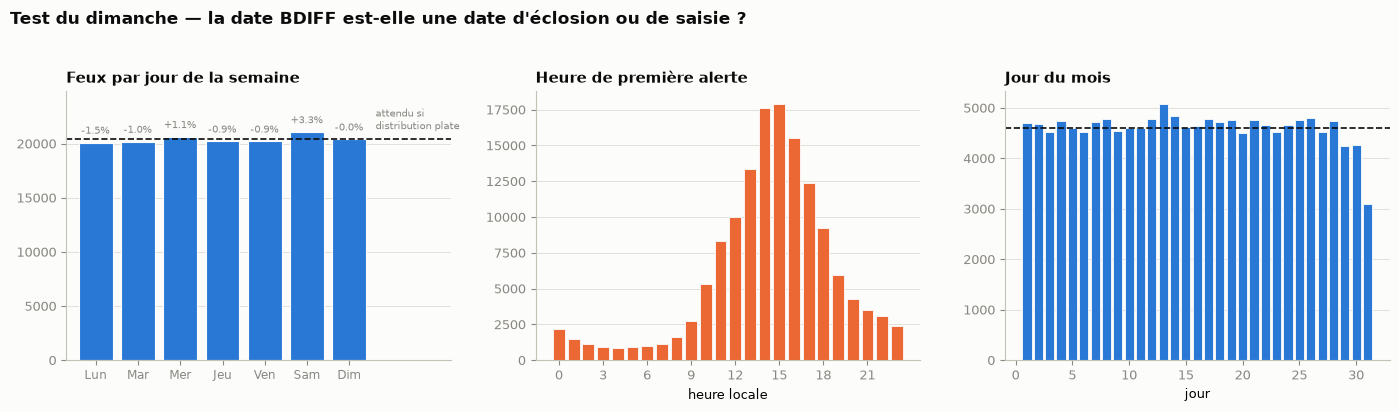

écart max au jour de semaine attendu : 3.3 %  (Samedi)
lignes à minuit pile (= sans heure)  : 0.2%
ratio 1er du mois / autres jours     : 1.02

✅ GRILLE JOUR VALIDÉE — distribution plate, heures réelles, pas d'arrondi.
   La date est bien une date d'éclosion/alerte. On peut modéliser au jour.


In [4]:
"""FIG 1 — LE TEST DU DIMANCHE. Bloquant : il décide de la granularité du modèle."""
FEU = BRUT.copy()
FEU["an"]    = FEU.dt.dt.year
FEU["mois"]  = FEU.dt.dt.month
FEU["doy"]   = FEU.dt.dt.dayofyear
FEU["jsem"]  = FEU.dt.dt.dayofweek
FEU["heure"] = FEU.dt.dt.hour
FEU["jmois"] = FEU.dt.dt.day
FEU["ha"]    = FEU["Surface parcourue (m2)"] / 10_000

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))

# (a) jour de la semaine — un creux le week-end trahirait une date de SAISIE
vc = FEU.jsem.value_counts().sort_index()
att = vc.sum() / 7
ecart = 100 * (vc - att) / att
cols = [ROUGE if abs(e) > 10 else BLEU for e in ecart]
ax[0].bar(range(7), vc.values, color=cols, edgecolor="#fcfcfb", linewidth=.8)
ax[0].axhline(att, color=INK, ls="--", lw=1.2)
# libellé placé HORS des barres, à droite : au-dessus d'elles il devenait illisible
ax[0].text(6.62, att * 1.03, "attendu si\ndistribution plate", va="bottom", ha="left",
           fontsize=7.5, color=MUTED)
for i, (v, e) in enumerate(zip(vc.values, ecart)):
    ax[0].text(i, v + att * .04, f"{e:+.1f}%", ha="center", fontsize=7.5, color=MUTED)
ax[0].set_xticks(range(7)); ax[0].set_xticklabels([j[:3] for j in JOURS], fontsize=8.5)
ax[0].set_title("Feux par jour de la semaine", fontsize=10.5, weight="bold", loc="left")
ax[0].set_ylim(0, vc.max() * 1.18); ax[0].set_xlim(-.7, 8.4)

# (b) heure de la journée — une date administrative n'aurait pas d'heure crédible
vh = FEU.heure.value_counts().sort_index()
ax[1].bar(vh.index, vh.values, color=ORANGE, edgecolor="#fcfcfb", linewidth=.6)
ax[1].set_xticks(range(0, 24, 3))
ax[1].set_title("Heure de première alerte", fontsize=10.5, weight="bold", loc="left")
ax[1].set_xlabel("heure locale")

# (c) jour du mois — un pic au 1er trahirait un arrondi administratif
vj = FEU.jmois.value_counts().sort_index()
ax[2].bar(vj.index, vj.values, color=BLEU, edgecolor="#fcfcfb", linewidth=.6)
ax[2].axhline(vj.mean(), color=INK, ls="--", lw=1.2)
ax[2].set_title("Jour du mois", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("jour")

for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Test du dimanche — la date BDIFF est-elle une date d'éclosion ou de saisie ?",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

# ── verdict chiffré ──
sans_heure = ((FEU.heure == 0) & (FEU.dt.dt.minute == 0)).mean()
r_1er = vj[1] / vj.drop(1).mean()
print(f"écart max au jour de semaine attendu : {ecart.abs().max():.1f} %  "
      f"({JOURS[int(ecart.abs().idxmax())]})")
print(f"lignes à minuit pile (= sans heure)  : {sans_heure:.1%}")
print(f"ratio 1er du mois / autres jours     : {r_1er:.2f}")
print()
plat  = ecart.abs().max() < 10
heure = sans_heure < .05
rond  = r_1er < 1.15
if plat and heure and rond:
    print("✅ GRILLE JOUR VALIDÉE — distribution plate, heures réelles, pas d'arrondi.")
    print("   La date est bien une date d'éclosion/alerte. On peut modéliser au jour.")
else:
    print("⚠️  Signaux de date administrative → envisager le repli sur la semaine.")

## 4. Le biais de collecte — la limite n°1 de cette base

La BDIFF n'a pas toujours couvert le même territoire. Le dispositif **Prométhée** suit les 15 départements méditerranéens depuis 1973 ; le reste de la France n'est intégré que bien plus tard.

Conséquence : une commune du Nord sans feu avant 2006 n'est pas une commune sans risque — **c'est une commune non observée**. C'est une différence que le modèle ne peut pas deviner, et qu'il faut donc traiter au cadrage.

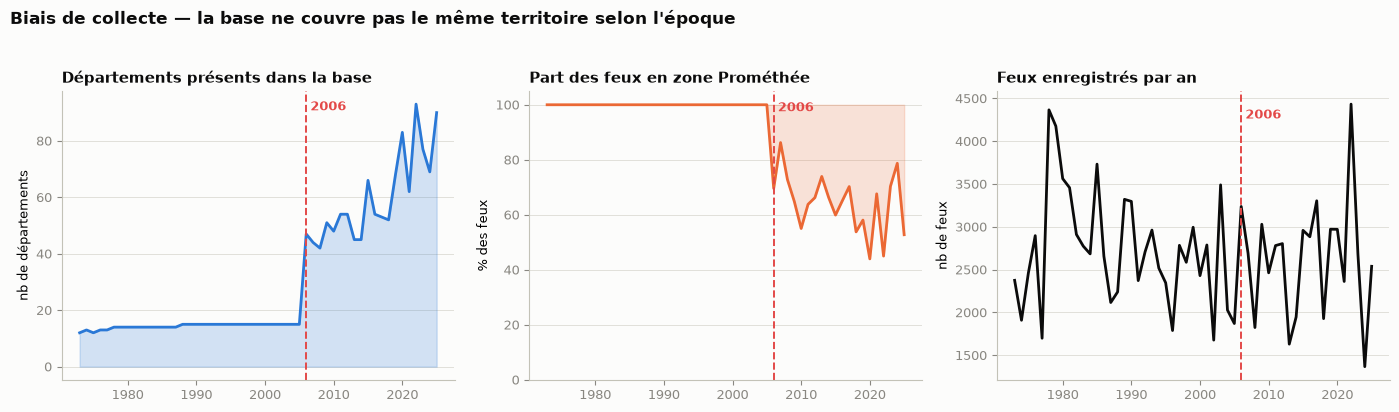

avant 2006 : 12–15 départements, 100 % des feux en zone Prométhée
depuis 2006 : 42–93 départements, 64 % en zone Prométhée

⚠️  Un modèle entraîné sur 1973–2005 apprendrait la géographie de la COLLECTE,
    pas celle du risque. Deux parades : restreindre le périmètre au méditerranéen,
    ou ne garder que 2006+. À trancher au cadrage.


In [5]:
"""FIG 2 — LE BIAIS DE COLLECTE. La limite n°1 de la BDIFF, à documenter noir sur blanc."""
# Zone Prométhée : les 15 départements méditerranéens suivis en continu depuis 1973.
PROMETHEE = {"04", "05", "06", "07", "11", "13", "26", "2A", "2B", "30", "34", "48", "66", "83", "84"}
FEU["prom"] = FEU["Département"].isin(PROMETHEE)

par_an = FEU.groupby("an").agg(deps=("Département", "nunique"), feux=("Numéro", "size"))
part_prom = FEU.groupby("an").prom.mean() * 100

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))

ax[0].fill_between(par_an.index, par_an.deps, color=BLEU, alpha=.2)
ax[0].plot(par_an.index, par_an.deps, color=BLEU, lw=2)
ax[0].set_title("Départements présents dans la base", fontsize=10.5, weight="bold", loc="left")
ax[0].set_ylabel("nb de départements")

ax[1].fill_between(part_prom.index, part_prom.values, 100, color=ORANGE, alpha=.18)
ax[1].plot(part_prom.index, part_prom.values, color=ORANGE, lw=2)
ax[1].set_ylim(0, 105)
ax[1].set_title("Part des feux en zone Prométhée", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("% des feux")

ax[2].plot(par_an.index, par_an.feux, color=INK, lw=2)
ax[2].set_title("Feux enregistrés par an", fontsize=10.5, weight="bold", loc="left")
ax[2].set_ylabel("nb de feux")

# la rupture : première année où la couverture explose
RUPTURE = int(par_an.deps.diff().idxmax())
for a in ax:
    a.axvline(RUPTURE, color=ROUGE, ls="--", lw=1.4)
    a.text(RUPTURE + .6, a.get_ylim()[1] * .93, str(RUPTURE), color=ROUGE,
           fontsize=9, weight="bold")
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Biais de collecte — la base ne couvre pas le même territoire selon l'époque",
             fontsize=12.5, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

av, ap = par_an.loc[:RUPTURE - 1], par_an.loc[RUPTURE:]
print(f"avant {RUPTURE} : {av.deps.min():2d}–{av.deps.max():2d} départements, "
      f"{part_prom.loc[:RUPTURE-1].mean():.0f} % des feux en zone Prométhée")
print(f"depuis {RUPTURE} : {ap.deps.min():2d}–{ap.deps.max():2d} départements, "
      f"{part_prom.loc[RUPTURE:].mean():.0f} % en zone Prométhée")
print(f"\n⚠️  Un modèle entraîné sur 1973–{RUPTURE-1} apprendrait la géographie de la COLLECTE,")
print( "    pas celle du risque. Deux parades : restreindre le périmètre au méditerranéen,")
print(f"    ou ne garder que {RUPTURE}+. À trancher au cadrage.")

## 5. Saisonnalité

Deux questions : à quoi ressemble l'année type, et **le 14 juillet ressort-il** ?

Pour le 14 juillet, comparer au niveau moyen de l'année ne prouverait rien — juillet est *déjà* un mois à feux. On compare donc chaque date à son **voisinage immédiat (±10 jours)** : c'est le seul test qui isole l'effet du jour férié du pic estival général.

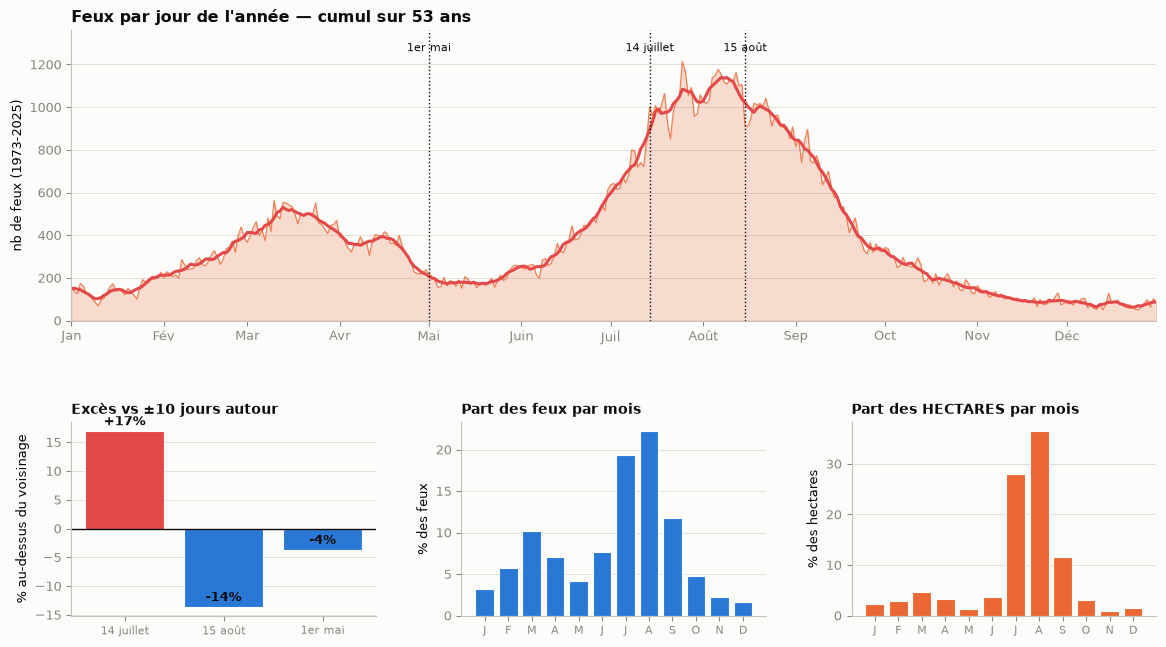

Test du 14 juillet — un pic existe-t-il, au-delà du pic estival général ?
   14 juillet  : 1,000 feux   voisinage ±10j = 855   excès +17 %
   15 août     : 913 feux   voisinage ±10j = 1,057   excès -14 %
   1er mai     : 220 feux   voisinage ±10j = 228   excès -4 %

Pic de fréquence : Août (22 % des feux)
Pic de surface   : Août (36 % des hectares)


In [6]:
"""FIG 3 — SAISONNALITÉ : les 365 jours + le test du 14 juillet."""
vc_doy = FEU[FEU.doy <= 365].doy.value_counts().sort_index().reindex(range(1, 366), fill_value=0)
liss = vc_doy.rolling(7, center=True, min_periods=1).mean()

fig = plt.figure(figsize=(14, 7.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.5, 1], hspace=.42, wspace=.28)

# (a) la courbe des 365 jours
axa = fig.add_subplot(gs[0, :])
axa.fill_between(vc_doy.index, vc_doy.values, color=ORANGE, alpha=.22)
axa.plot(vc_doy.index, vc_doy.values, color=ORANGE, lw=.8, alpha=.8)
axa.plot(liss.index, liss.values, color=ROUGE, lw=2.2)
FETES = {195: "14 juillet", 227: "15 août", 121: "1er mai"}
for d, lab in FETES.items():
    axa.axvline(d, color=INK, ls=":", lw=1)
    axa.text(d, vc_doy.max() * 1.04, lab, ha="center", fontsize=8, color=INK)
axa.set_xticks(DEB_MOIS); axa.set_xticklabels(MOIS, fontsize=9)
axa.set_xlim(1, 365); axa.set_ylim(0, vc_doy.max() * 1.12)
axa.set_ylabel("nb de feux (1973-2025)")
axa.set_title("Feux par jour de l'année — cumul sur 53 ans", fontsize=11.5, weight="bold", loc="left")

# (b) test du 14 juillet : comparaison à un VOISINAGE local, pas à la moyenne annuelle
axb = fig.add_subplot(gs[1, 0])
FEN = 10
for d, lab in FETES.items():
    voisins = [j for j in range(d - FEN, d + FEN + 1) if j != d and 1 <= j <= 365]
    base = vc_doy.loc[voisins].mean()
    exces = 100 * (vc_doy[d] - base) / base
    axb.bar(lab, exces, color=ROUGE if exces > 15 else BLEU,
            edgecolor="#fcfcfb", linewidth=.8)
    axb.text(lab, exces + 1, f"{exces:+.0f}%", ha="center", fontsize=9, weight="bold")
axb.axhline(0, color=INK, lw=1)
axb.set_title(f"Excès vs ±{FEN} jours autour", fontsize=10, weight="bold", loc="left")
axb.set_ylabel("% au-dessus du voisinage")
axb.tick_params(axis="x", labelsize=8)

# (c) répartition mensuelle
axc = fig.add_subplot(gs[1, 1])
vm = FEU.mois.value_counts().sort_index()
axc.bar(range(1, 13), 100 * vm.values / vm.sum(), color=BLEU,
        edgecolor="#fcfcfb", linewidth=.8)
axc.set_xticks(range(1, 13)); axc.set_xticklabels([m[0] for m in MOIS], fontsize=8)
axc.set_title("Part des feux par mois", fontsize=10, weight="bold", loc="left")
axc.set_ylabel("% des feux")

# (d) surface brûlée par mois — le calendrier des feux ≠ celui des hectares
axd = fig.add_subplot(gs[1, 2])
sm = FEU.groupby("mois").ha.sum()
axd.bar(range(1, 13), 100 * sm.values / sm.sum(), color=ORANGE,
        edgecolor="#fcfcfb", linewidth=.8)
axd.set_xticks(range(1, 13)); axd.set_xticklabels([m[0] for m in MOIS], fontsize=8)
axd.set_title("Part des HECTARES par mois", fontsize=10, weight="bold", loc="left")
axd.set_ylabel("% des hectares")

for a in [axa, axb, axc, axd]:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
plt.show()

print("Test du 14 juillet — un pic existe-t-il, au-delà du pic estival général ?")
for d, lab in FETES.items():
    voisins = [j for j in range(d - FEN, d + FEN + 1) if j != d and 1 <= j <= 365]
    base = vc_doy.loc[voisins].mean()
    print(f"   {lab:11s} : {vc_doy[d]:,} feux   voisinage ±{FEN}j = {base:,.0f}   "
          f"excès {100*(vc_doy[d]-base)/base:+.0f} %")
print(f"\nPic de fréquence : {MOIS[int(vm.idxmax())-1]} ({100*vm.max()/vm.sum():.0f} % des feux)")
print(f"Pic de surface   : {MOIS[int(sm.idxmax())-1]} ({100*sm.max()/sm.sum():.0f} % des hectares)")

## 6. Vue d'ensemble année × jour

La heatmap montre d'un coup la saison, son déplacement, et la rupture de collecte. Le spaghetti cumulé suit la logique des courbes de banquise arctique : **le cumul est monotone**, donc les courbes s'empilent au lieu de se croiser — c'est ce qui les rend lisibles.

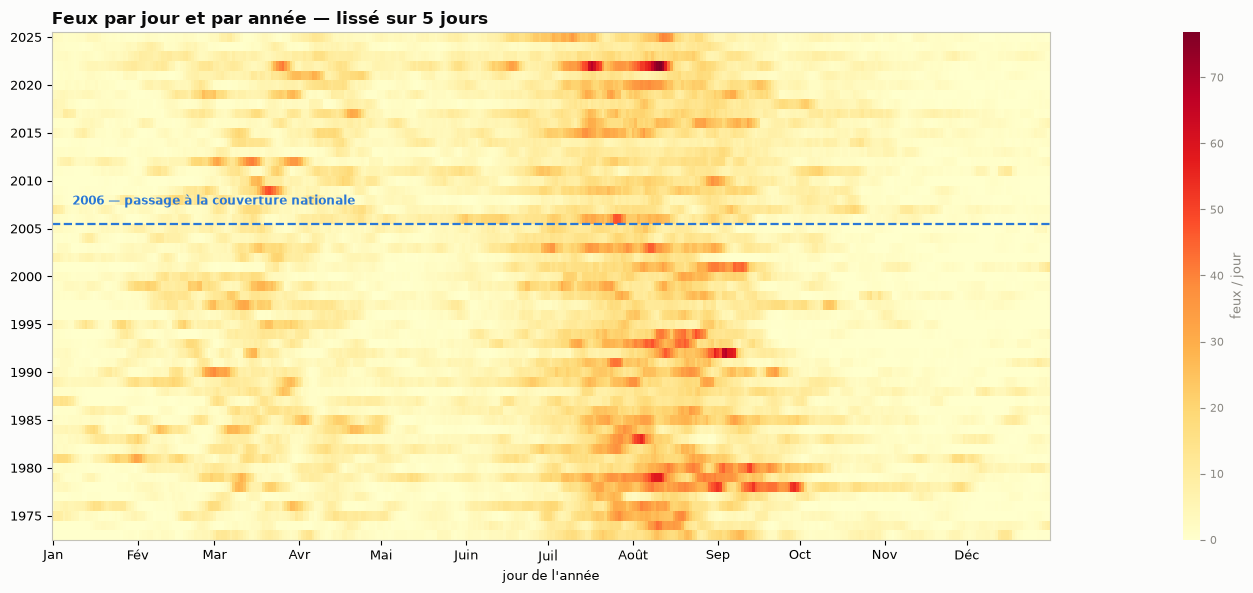

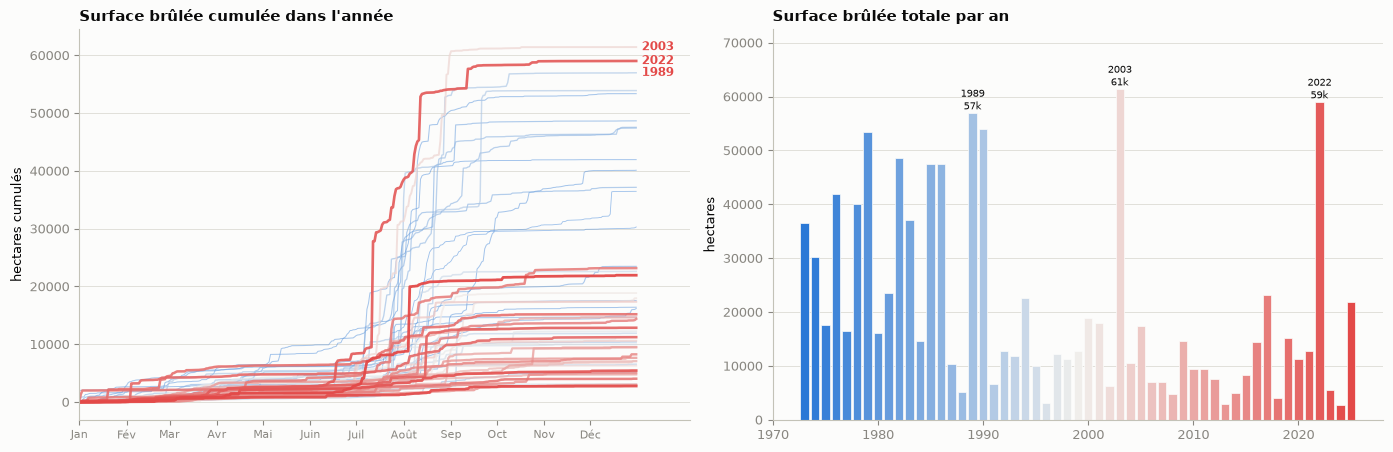

Années les plus brûlées :
   2003 :    61,424 ha
   2022 :    59,021 ha
   1989 :    56,973 ha
   1990 :    53,897 ha
   1979 :    53,365 ha


In [7]:
"""FIG 4 — HEATMAP année × jour  ·  FIG 5 — spaghetti cumulé des surfaces."""
# ── FIG 4 : heatmap ──
piv = (FEU[FEU.doy <= 365].groupby(["an", "doy"]).size()
       .unstack(fill_value=0).reindex(columns=range(1, 366), fill_value=0))
piv_l = piv.T.rolling(5, center=True, min_periods=1).mean().T   # pandas 3 : plus d'argument axis=

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(piv_l.columns, piv_l.index, piv_l.values, cmap="YlOrRd", shading="nearest")
ax.axhline(RUPTURE - .5, color="#2a78d6", lw=1.6, ls="--")
# annotation À L'INTÉRIEUR du cadre : à droite elle passait sous la barre de couleur
ax.text(8, RUPTURE + 1.2, f"{RUPTURE} — passage à la couverture nationale", color="#2a78d6",
        fontsize=8.5, va="bottom", weight="bold")
ax.set_xticks(DEB_MOIS); ax.set_xticklabels(MOIS, fontsize=9)
ax.set_yticks(range(1975, 2026, 5))
ax.set_title("Feux par jour et par année — lissé sur 5 jours", fontsize=12, weight="bold", loc="left")
ax.set_xlabel("jour de l'année")
cb = fig.colorbar(im, ax=ax, pad=.10, aspect=30)
cb.set_label("feux / jour", fontsize=9, color=MUTED); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, colors=MUTED)
plt.tight_layout(); plt.show()

# ── FIG 5 : spaghetti cumulé (le graphique « banquise arctique ») ──
# Le cumul est monotone : les courbes s'empilent au lieu de se croiser → lisible.
cum = (FEU[FEU.doy <= 365].groupby(["an", "doy"]).ha.sum()
       .unstack(fill_value=0).reindex(columns=range(1, 366), fill_value=0)
       .cumsum(axis=1))
ANS = cum.index.values
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

for i, an in enumerate(ANS):
    r = i / (len(ANS) - 1)
    ax[0].plot(cum.columns, cum.loc[an], color=CM_ANNEES(r), lw=.6 + 1.4 * r, alpha=.45 + .5 * r)
top3 = cum.iloc[:, -1].nlargest(3).index
for an in top3:
    ax[0].text(366, cum.loc[an].iloc[-1], f" {an}", fontsize=8.5, weight="bold",
               va="center", color=ROUGE)
ax[0].set_title("Surface brûlée cumulée dans l'année", fontsize=11, weight="bold", loc="left")
ax[0].set_ylabel("hectares cumulés"); ax[0].set_xlim(1, 400)
ax[0].set_xticks(DEB_MOIS); ax[0].set_xticklabels(MOIS, fontsize=8)

tot = FEU.groupby("an").ha.sum()
ax[1].bar(tot.index, tot.values, color=[CM_ANNEES(i / (len(tot) - 1)) for i in range(len(tot))],
          edgecolor="#fcfcfb", linewidth=.5)
ax[1].set_title("Surface brûlée totale par an", fontsize=11, weight="bold", loc="left")
ax[1].set_ylabel("hectares")
for an in top3:
    ax[1].text(an, tot[an], f"{an}\n{tot[an]/1000:.0f}k", ha="center", va="bottom",
               fontsize=7.5, color=INK)
ax[1].set_ylim(0, tot.max() * 1.18)

for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
plt.tight_layout(); plt.show()

print("Années les plus brûlées :")
for an in tot.nlargest(5).index:
    print(f"   {an} : {tot[an]:>9,.0f} ha")

## 7. Surfaces, causes et géographie

La distribution des surfaces est **très déséquilibrée** : une poignée de feux fait l'essentiel des hectares. C'est une caractéristique structurelle des feux de forêt, et elle a une conséquence directe sur la modélisation — la moyenne n'est pas une statistique pertinente ici.

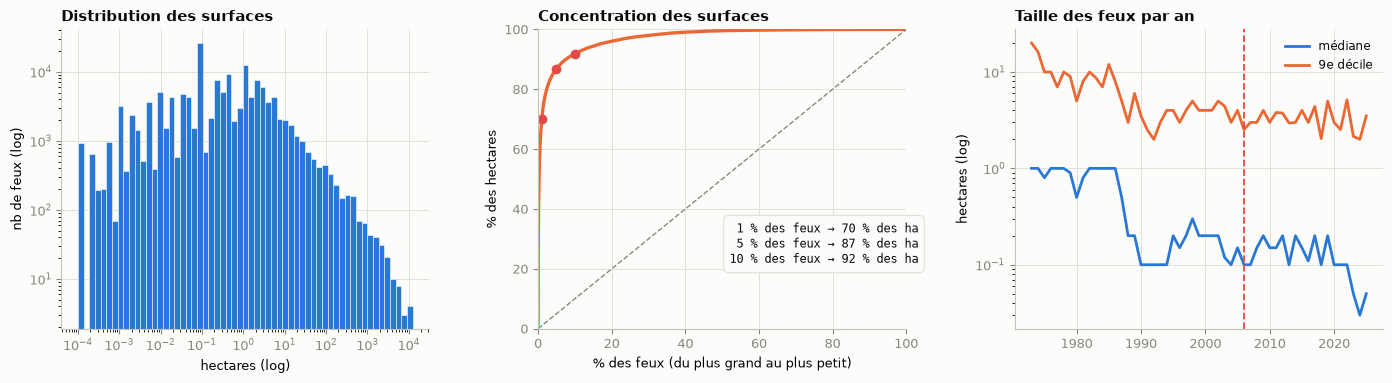

   les  1 % de feux les plus grands font 70.0 % des hectares
   les  5 % de feux les plus grands font 86.9 % des hectares
   les 10 % de feux les plus grands font 91.9 % des hectares
   les 50 % de feux les plus grands font 99.6 % des hectares

   surface médiane : 0.20 ha   ·   moyenne : 7.6 ha → écart typique d'une loi en puissance


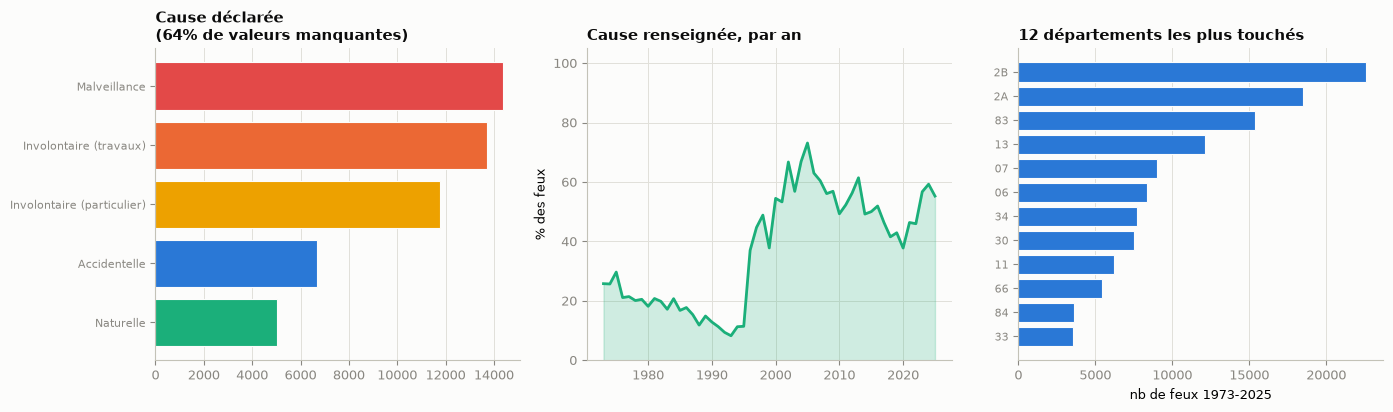

Top 5 départements par surface brûlée :
   2B :   236,317 ha
   83 :   142,629 ha
   2A :   110,602 ha
   13 :    95,268 ha
   06 :    64,846 ha

Communes distinctes touchées : 10,081
Feux les plus grands :
   2022 · Landiras (33) : 12,552 ha
   1990 · Vidauban (83) : 11,580 ha
   2025 · Ribaute (11) : 11,133 ha


In [8]:
"""FIG 6 — SURFACES : une loi très déséquilibrée. FIG 7 — causes et géographie."""
# ── FIG 6 : distribution des surfaces ──
ha = FEU.ha[FEU.ha > 0]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))

bins = np.logspace(np.log10(ha.min()), np.log10(ha.max()), 60)
ax[0].hist(ha, bins=bins, color=BLEU, edgecolor="#fcfcfb", linewidth=.4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_title("Distribution des surfaces", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("hectares (log)"); ax[0].set_ylabel("nb de feux (log)")

# courbe de concentration : quelle part des hectares vient des plus gros feux ?
s = ha.sort_values(ascending=False).values
part_feux = np.arange(1, len(s) + 1) / len(s) * 100
part_ha = np.cumsum(s) / s.sum() * 100
ax[1].plot(part_feux, part_ha, color=ORANGE, lw=2.4)
ax[1].plot([0, 100], [0, 100], color=MUTED, ls="--", lw=1)
# annotations regroupées : côte à côte sur la courbe, elles se chevauchaient
lignes_c = []
for p in (1, 5, 10):
    y = part_ha[int(len(s) * p / 100)]
    ax[1].plot([p], [y], "o", color=ROUGE, ms=6)
    lignes_c.append(f"{p:>2} % des feux → {y:.0f} % des ha")
ax[1].text(52, 22, "\n".join(lignes_c), fontsize=8.5, color=INK, family="monospace",
           bbox=dict(boxstyle="round,pad=0.5", facecolor="#fcfcfb",
                     edgecolor="#e1e0d9", linewidth=.9))
ax[1].set_xlim(0, 100); ax[1].set_ylim(0, 100)
ax[1].set_title("Concentration des surfaces", fontsize=10.5, weight="bold", loc="left")
ax[1].set_xlabel("% des feux (du plus grand au plus petit)"); ax[1].set_ylabel("% des hectares")

# taille médiane par an — la BDIFF a-t-elle changé de seuil de saisie ?
med = FEU.groupby("an").ha.median()
q90 = FEU.groupby("an").ha.quantile(.9)
ax[2].plot(med.index, med.values, color=BLEU, lw=2, label="médiane")
ax[2].plot(q90.index, q90.values, color=ORANGE, lw=2, label="9e décile")
ax[2].axvline(RUPTURE, color=ROUGE, ls="--", lw=1.3)
ax[2].set_yscale("log")
ax[2].set_title("Taille des feux par an", fontsize=10.5, weight="bold", loc="left")
ax[2].set_ylabel("hectares (log)"); ax[2].legend(frameon=False, fontsize=8.5)

for a in ax:
    a.grid(color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
plt.tight_layout(); plt.show()

for p in (1, 5, 10, 50):
    print(f"   les {p:2d} % de feux les plus grands font {part_ha[int(len(s)*p/100)]:.1f} % des hectares")
print(f"\n   surface médiane : {ha.median():.2f} ha   ·   moyenne : {ha.mean():.1f} ha "
      f"→ écart typique d'une loi en puissance")

# ── FIG 7 : causes + géographie ──
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

nat = FEU.Nature.value_counts()
cols_nat = [ROUGE, ORANGE, "#eda100", BLEU, VERT][:len(nat)]
ax[0].barh(nat.index[::-1], nat.values[::-1], color=cols_nat[::-1],
           edgecolor="#fcfcfb", linewidth=.8)
ax[0].set_title(f"Cause déclarée\n({FEU.Nature.isna().mean():.0%} de valeurs manquantes)",
                fontsize=10.5, weight="bold", loc="left")
ax[0].tick_params(axis="y", labelsize=8)

# part renseignée au fil du temps : la qualité du champ s'améliore-t-elle ?
rens = FEU.groupby("an").Nature.apply(lambda s: s.notna().mean() * 100)
ax[1].fill_between(rens.index, rens.values, color=VERT, alpha=.2)
ax[1].plot(rens.index, rens.values, color=VERT, lw=2)
ax[1].set_ylim(0, 105)
ax[1].set_title("Cause renseignée, par an", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("% des feux")

top_dep = FEU.groupby("Département").agg(feux=("Numéro", "size"), ha=("ha", "sum")) \
             .nlargest(12, "feux").sort_values("feux")
ax[2].barh(top_dep.index, top_dep.feux, color=BLEU, edgecolor="#fcfcfb", linewidth=.8)
ax[2].set_title("12 départements les plus touchés", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("nb de feux 1973-2025"); ax[2].tick_params(axis="y", labelsize=8)

for a in ax:
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
ax[1].grid(axis="y", color=GRID, lw=.7)
plt.tight_layout(); plt.show()

print("Top 5 départements par surface brûlée :")
for d, r in FEU.groupby("Département").ha.sum().nlargest(5).items():
    print(f"   {d} : {r:>9,.0f} ha")
print(f"\nCommunes distinctes touchées : {FEU['Code INSEE'].nunique():,}")
print(f"Feux les plus grands :")
for _, r in FEU.nlargest(3, "ha")[["an", "Nom de la commune", "Département", "ha"]].iterrows():
    print(f"   {r.an} · {r['Nom de la commune']} ({r.Département}) : {r.ha:,.0f} ha")

## 8. Synthèse

### Ce qui est établi

| Point | Résultat |
|---|---|
| Intégrité | 142 787 feux, lignes lues = nombre annoncé par la BDIFF sur les 6 exports |
| **Doublons de frontière** | **Aucun** — la borne haute des exports est exclusive, les plages sont disjointes |
| Doublons internes BDIFF | ~1 800 lignes partagent commune + minute + surface avec des n° différents |
| **Test du dimanche** | ✅ **PASSÉ** — distribution plate, 99,8 % d'heures réelles, pas d'arrondi |
| **→ Granularité** | **La maille `commune × jour` est validée** |
| Couverture | 12-15 départements jusqu'en 2005, puis 42-93 → rupture nette en 2006 |
| Période réelle | 1973-2025 (rien avant 1973, malgré une demande depuis 1966) |

### Ce qui reste à trancher

1. **Périmètre** — méditerranéen sur 1973-2025, ou France entière sur 2006-2025 ? Les deux sont défendables ; ce qui ne l'est pas, c'est la France entière sur 1973-2025.
2. **Doublons internes** — vrais doublons de saisie, ou feux distincts au même horodatage ? À trancher avant de construire la cible `y`.
3. **Champs peu remplis** — `Nature` (64 % manquant) et `Type de peuplement` (45 %) : utilisables comme features seulement sur la période récente.

### Prochaine étape

Jointure au référentiel géographique (`code INSEE → lat/lon`) pour croiser avec la grille météo.